#インポート

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.ticker as ticker
import torchvision
from torchvision import models

#シード固定

In [11]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

#デバイス・データセット・モデル定義

In [12]:
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

Model = models.resnet18(weights=None)
Model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
Model.maxpool = nn.Identity()
Model.fc = nn.Linear(512, 10)

#学習率・エポック数・バッチサイズ指定、データローダー作る

In [13]:
set_seed(42)
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True, num_workers = 0)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False, num_workers = 0)

LEARNING_RATE = 0.01
EPOCHS = 50

#学習ループ

In [14]:
set_seed(42)
class Primal_NFG_SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)

    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["prev_a"] = torch.zeros_like(p)
                    state["z"] = torch.clone(p.detach())
                    state["prev_z"] = torch.clone(p.detach())

                state["prev_a"].copy_(state["a"])
                state["a"].zero_()
                state['prev_z'].copy_(state["z"])
                state["z"].zero_()
                state["t"] = 0

    def culc_prev_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["current_p"] = torch.clone(p) # 現在のパラメータをcurrent_pに保持
                    p.copy_(state["prev_z"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        # current_pに切り替え，prev_gradの保持
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["current_p"]) # パラメータをcurrent_pに変換
                    state["prev_grad"] = torch.clone(p.grad.detach())

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        # ---- 【追加】それぞれのノルムの二乗和を保持する変数 ----
        total_grad_norm_sq = 0.0
        total_v_norm_sq = 0.0
        # ----------------------------------------------------

        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                # ① ミニバッチ勾配のノルム二乗を足し込む
                total_grad_norm_sq += grad.norm(2).item() ** 2

                state = self.state[p]
                a = state['a']
                prev_a = state["prev_a"]
                prev_grad = state["prev_grad"]
                z = state["z"]
                t = state["t"]

                # 平均勾配を更新
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))
                
                # 補正勾配を更新
                v = grad - prev_grad + prev_a
                # ② 補正勾配vのノルム二乗を足し込む
                total_v_norm_sq += v.norm(2).item() ** 2

                # パラメータを更新
                p.sub_(v, alpha = lr)
                # 平均パラメーターを更新
                z.mul_(t / (t+1)).add_(p, alpha = 1 / (t+1))
                state["t"] += 1

        # 平方根をとって全体のL2ノルムを計算
        grad_norm = total_grad_norm_sq ** 0.5
        v_norm = total_v_norm_sq ** 0.5
        
        # 二つのノルムをタプルで返す
        return grad_norm, v_norm

In [15]:
set_seed(42)
model = Model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = Primal_NFG_SVRG(model.parameters(), lr = LEARNING_RATE)

Primal_NFG_SVRG_train_loss_history = []
Primal_NFG_SVRG_test_loss_history = []
Primal_NFG_SVRG_train_acc_history = []
Primal_NFG_SVRG_test_acc_history = []
Primal_NFG_SVRG_x = []
fg_count = 0

# ---- 【追加】3つのノルム用の履歴リスト ----
grad_norm_history = []   # ① ミニバッチ勾配のノルム
v_norm_history = []      # ② 補正勾配vのノルム
param_norm_history = []  # ③ パラメータのノルム
# -------------------------------------------

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    train_loss, correct, total = 0, 0, 0

    optimizer.init_epoch()

    pb = tqdm(train_loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.culc_prev_grads(model, X, T, criterion)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()

        # ---- 【変更】オプティマイザから2つのノルムを取得 ----
        grad_norm, v_norm = optimizer.step() 
        grad_norm_history.append(grad_norm)
        v_norm_history.append(v_norm)
        # --------------------------------------------------

        # ---- 【追加】③ パラメータ全体のL2ノルムを計算 ----
        total_param_norm = 0.0
        for p in model.parameters():
            param_norm = p.detach().data.norm(2)
            total_param_norm += param_norm.item() ** 2
        total_param_norm = total_param_norm ** 0.5
        param_norm_history.append(total_param_norm)
        # --------------------------------------------------

        train_loss += loss.item()

        pred = Y.argmax(dim=1)
        correct += (pred == T).sum().item()
        total += T.size(0)

        # tqdmのプログレスバーに3つのノルムをすべて表示
        pb.set_postfix({
            "loss": f"{loss.item():.4f}", 
            "acc": f"{correct / total:.4f}",
            "g_norm": f"{grad_norm:.3f}",  # 通常勾配
            "v_norm": f"{v_norm:.3f}",     # 補正勾配
            "p_norm": f"{total_param_norm:.1f}" # パラメータ
        })

    fg_count += 2
    train_loss /= len(train_loader)
    train_acc = correct / total

    Primal_NFG_SVRG_x.append(fg_count)
    Primal_NFG_SVRG_train_loss_history.append(train_loss)
    Primal_NFG_SVRG_train_acc_history.append(train_acc)


    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        pb = tqdm(test_loader)

        backup = []
        with torch.no_grad():
            for group in optimizer.param_groups:
                for p in group['params']:
                    state = optimizer.state[p]
                    backup.append(p.clone())
                    p.copy_(state["z"])

        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        with torch.no_grad():
            i = 0
            for group in optimizer.param_groups:
                for p in group['params']:
                    p.copy_(backup[i])
                    i += 1

    test_loss /= len(test_loader)
    test_acc = correct / total

    Primal_NFG_SVRG_test_loss_history.append(test_loss)
    Primal_NFG_SVRG_test_acc_history.append(test_acc)

    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

    if fg_count >= EPOCHS:
        break

epoch: 1


100%|██████████| 157/157 [00:01<00:00, 81.56it/s, loss=2.41, acc=0.108]


Train Loss: 2.3989, Acc: 0.1074 | Test Loss: 2.4060, Acc: 0.1081
epoch: 2


100%|██████████| 157/157 [00:01<00:00, 82.97it/s, loss=1.65, acc=0.346]


Train Loss: 1.6438, Acc: 0.3988 | Test Loss: 1.8610, Acc: 0.3456
epoch: 3


...

Train Loss: 825224512637676416.0000, Acc: 0.1103 | Test Loss: 5055725238979292160.0000, Acc: 0.1000
epoch: 24


100%|██████████| 157/157 [00:01<00:00, 90.21it/s, loss=1.87e+20, acc=0.1]   


Train Loss: 28302389028663468032.0000, Acc: 0.1115 | Test Loss: 192228347231459999744.0000, Acc: 0.1000
epoch: 25


100%|██████████| 157/157 [00:01<00:00, 89.62it/s, loss=3.67e+21, acc=0.1]   

Train Loss: 294128426575531016192.0000, Acc: 0.1035 | Test Loss: 3772795461837344735232.0000, Acc: 0.1000


#結果

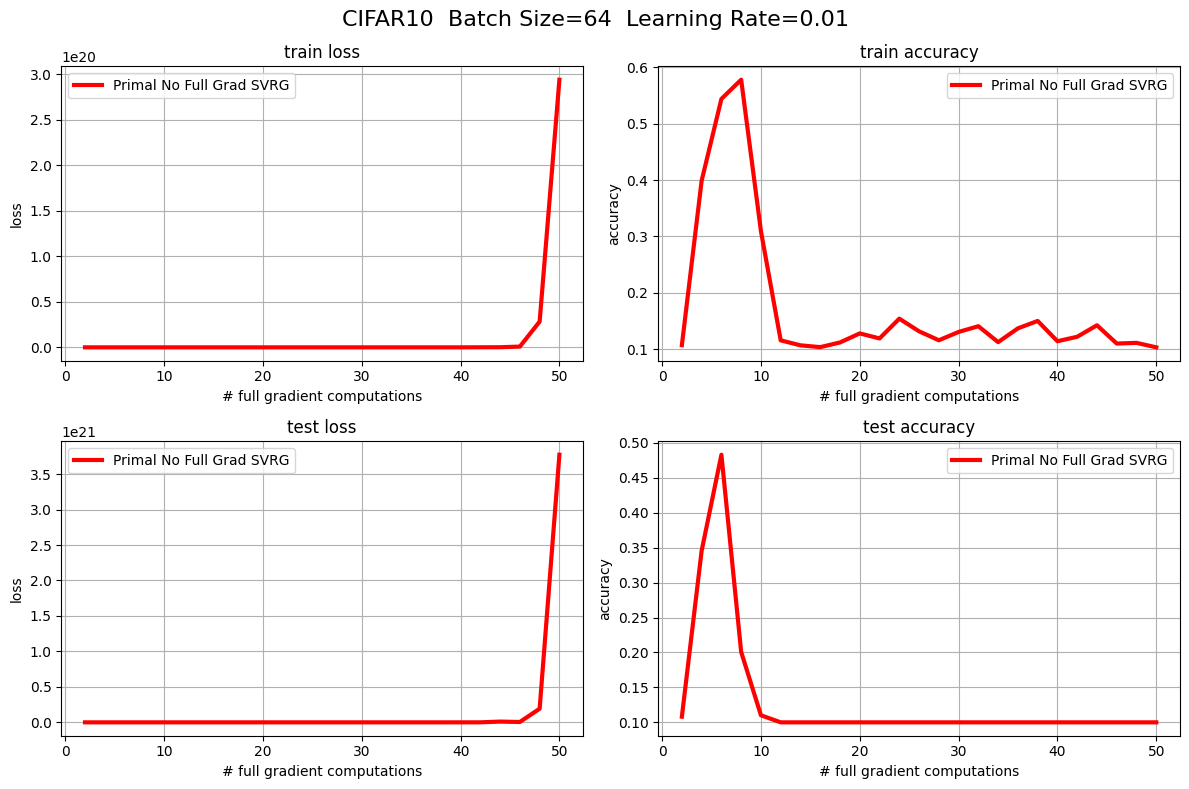

In [16]:
fig = plt.figure(figsize = (12, 8))
fig.suptitle(f"CIFAR10  Batch Size={BATCH_SIZE}  Learning Rate={LEARNING_RATE}",fontsize=16)
ax = fig.add_subplot(2, 2, 1)
ax.plot(Primal_NFG_SVRG_x, Primal_NFG_SVRG_train_loss_history, label = "Primal No Full Grad SVRG", c='red',  linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("train loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 2)
ax.plot(Primal_NFG_SVRG_x, Primal_NFG_SVRG_train_acc_history, label = "Primal No Full Grad SVRG", c='red', linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("train accuracy")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 3)
ax.plot(Primal_NFG_SVRG_x, Primal_NFG_SVRG_test_loss_history, label = "Primal No Full Grad SVRG", c='red', linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("test loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 4)
ax.plot(Primal_NFG_SVRG_x, Primal_NFG_SVRG_test_acc_history, label = "Primal No Full Grad SVRG", c='red', linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("test accuracy")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()

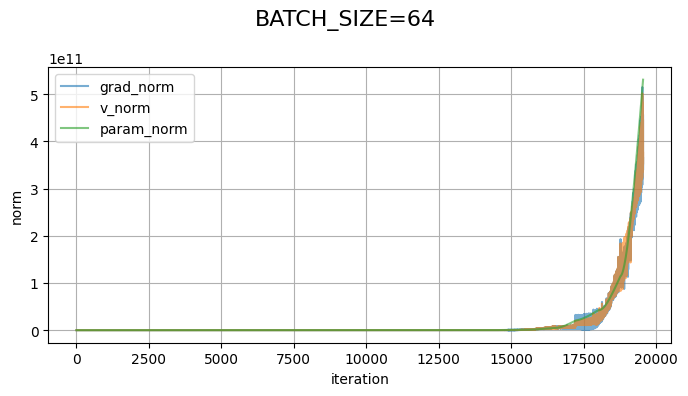

In [17]:
fig = plt.figure(figsize=(7, 4))
fig.suptitle(f'BATCH_SIZE={BATCH_SIZE}', fontsize=16)
ax = fig.add_subplot(1, 1, 1)
ax.plot(grad_norm_history, label="grad_norm", alpha=0.6)
ax.plot(v_norm_history, label="v_norm", alpha=0.6)
ax.plot(param_norm_history, label="param_norm", alpha=0.6)
ax.set_xlabel("iteration")
ax.set_ylabel("norm")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()